# 5. Evaluación (CRISP-DM)
### Reto técnico ML Engineering · High Garden Coffee

La fase 4 ya midió el modelo por dentro (MASE, calibración, Brier). Esta fase responde otras tres preguntas, que son las de
negocio y de proceso:

1. ¿Se cumplieron los **criterios de éxito** que se fijaron en la fase 1?
2. ¿El resultado es **accionable** para el área comercial y **robusto** frente a decisiones técnicas?
3. ¿Qué se hace con esto: **desplegar, iterar o descartar**?

No se entrena nada: se leen los artefactos que dejó el modelado.

## 5.0 Carga de artefactos

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path(
    r"C:\Users\david\Desktop\Personal\github_master\prueba-nttdata\data"
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

balance = pd.read_parquet(DATA_DIR / "coffee_balance_long.parquet")
ranking = pd.read_parquet(DATA_DIR / "outputs" / "modelado_ranking.parquet").set_index("country")
ranking_ingenuo = pd.read_parquet(DATA_DIR / "outputs" / "modelado_ranking_ingenuo.parquet").set_index("country")
proyeccion = pd.read_parquet(DATA_DIR / "outputs" / "modelado_proyeccion.parquet")
backtesting = pd.read_parquet(DATA_DIR / "outputs" / "modelado_backtesting.parquet")
calibracion = pd.read_parquet(DATA_DIR / "outputs" / "modelado_calibracion.parquet")
elegidos = pd.read_parquet(DATA_DIR / "outputs" / "modelado_modelos_elegidos.parquet")

ANIO_OBJETIVO = ranking["crop_year"].iloc[0]
print(f"países evaluados: {len(ranking)} | año objetivo: {ANIO_OBJETIVO}")

países evaluados: 45 | año objetivo: 2022/23


## 5.1 Criterios de éxito técnicos

La fase 1 fijó cuatro criterios. Se verifican uno por uno con los artefactos del modelado, sin recalcular nada.

In [3]:
mase_por_serie = (backtesting.groupby(["country", "variable", "modelo"])["mase"].mean().rename("mase").reset_index()
                  .merge(elegidos.rename(columns={"modelo": "elegido"}), on=["country", "variable"]))
elegido_mase = mase_por_serie.query("modelo == elegido").set_index(["country", "variable"])["mase"]
ingenuo_mase = mase_por_serie.query("modelo == 'ingenuo'").set_index(["country", "variable"])["mase"]

supera = (elegido_mase < ingenuo_mase).mean()
bajo_uno = (elegido_mase < 1).mean()

extremos = calibracion[(calibracion["prob_pronosticada"] >= 0.95) | (calibracion["prob_pronosticada"] <= 0.05)]
acierto_extremos = (extremos["prob_pronosticada"].round() == extremos["deficit_real"]).mean()

orden = ranking[["necesidad_esperada_sacos"]].join(ranking_ingenuo[["necesidad_esperada_sacos_ingenuo"]])
correlacion = orden.corr(method="spearman").iloc[0, 1]
top5_igual = len(set(orden.nlargest(5, "necesidad_esperada_sacos").index)
                 & set(orden.nlargest(5, "necesidad_esperada_sacos_ingenuo").index))

print(f"MASE del modelo elegido < 1: {bajo_uno:.0%} de las series")
print(f"supera al ingenuo: {supera:.0%} de las series")
print(f"acierto en probabilidades extremas (≥95 % o ≤5 %): {acierto_extremos:.0%} de {len(extremos)} casos")
print(f"correlación de Spearman entre el ranking elegido y el ranking ingenuo: {correlacion:.2f}")
print(f"coincidencia en el top 5: {top5_igual} de 5")

MASE del modelo elegido < 1: 69% de las series
supera al ingenuo: 52% de las series
acierto en probabilidades extremas (≥95 % o ≤5 %): 99% de 367 casos
correlación de Spearman entre el ranking elegido y el ranking ingenuo: 0.92
coincidencia en el top 5: 5 de 5


In [4]:
criterios = pd.DataFrame([
    ["MASE < 1 en la mayoría de las series modelables", "> 50 %", f"{bajo_uno:.0%}",
     "Cumple" if bajo_uno > 0.5 else "No cumple"],
    ["El modelo elegido supera al ingenuo", "mayoría de series", f"{supera:.0%}",
     "Parcial" if 0.4 < supera <= 0.6 else ("Cumple" if supera > 0.6 else "No cumple")],
    ["Probabilidades calibradas", "cercanas a su frecuencia real", "solo en los extremos",
     "Parcial"],
    ["Ranking estable frente al modelo", "top 5 estable", f"Spearman {correlacion:.2f}, top 5: {top5_igual}/5",
     "Cumple" if top5_igual >= 4 else "Parcial"],
    ["Pipeline reproducible de punta a punta", "sí", "5 notebooks encadenados por archivos", "Cumple"],
], columns=["Criterio (fase 1)", "Meta", "Resultado", "Veredicto"])
criterios

,Criterio (fase 1),Meta,Resultado,Veredicto
0,MASE < 1 en la mayoría de las series modelables,> 50 %,69%,Cumple
1,El modelo elegido supera al ingenuo,mayoría de series,52%,Parcial
2,Probabilidades calibradas,cercanas a su frecuencia real,solo en los extremos,Parcial
3,Ranking estable frente al modelo,top 5 estable,"Spearman 0.92, top 5: 5/5",Cumple
4,Pipeline reproducible de punta a punta,sí,5 notebooks encadenados por archivos,Cumple


## 5.2 ¿El ranking depende del modelo elegido?

Una recomendación comercial no puede cambiar de orden según una decisión técnica interna. Para comprobarlo se compara el
ranking final contra uno construido forzando el modelo ingenuo en todas las series: si ambos coinciden en la parte alta,
la conclusión proviene de los datos y no del modelo.

In [5]:
comparacion = (orden.assign(
    posicion=lambda d: d["necesidad_esperada_sacos"].rank(ascending=False).astype(int),
    posicion_ingenuo=lambda d: d["necesidad_esperada_sacos_ingenuo"].rank(ascending=False).astype(int))
    .sort_values("posicion").head(10))
comparacion[["posicion", "posicion_ingenuo", "necesidad_esperada_sacos", "necesidad_esperada_sacos_ingenuo"]].round(0)

,posicion,posicion_ingenuo,necesidad_esperada_sacos,necesidad_esperada_sacos_ingenuo
country,,,,
Philippines,1,1,4088042.0,4004470.0
Thailand,2,2,1270967.0,1335540.0
Venezuela,3,3,173015.0,735027.0
Cuba,4,4,82582.0,80758.0
Madagascar,5,5,30571.0,26724.0
Mexico,6,7,9509.0,11021.0
El Salvador,7,8,7800.0,10861.0
Central African Republic,8,9,4691.0,4237.0
Haiti,9,10,3273.0,3905.0


## 5.3 La recomendación comercial

El criterio de negocio de la fase 1 pedía una lista de 5 a 10 mercados, justificada y entendible. Se construye combinando
tres cosas que ya están calculadas: el volumen esperado, la probabilidad y la confiabilidad de la serie.

La acción sugerida traduce esas cifras a una decisión, no a un número más:

- **Prioridad alta:** déficit prácticamente seguro (probabilidad ≥ 80 %) y volumen relevante (≥ 100 mil sacos).
- **Prioridad alta con reserva:** cumple lo anterior, pero la serie del país es débil. La dirección es clara y la magnitud no;
  es el caso de Filipinas, cuya producción se modela con 10 observaciones.
- **Prioridad media:** el déficit es probable o el volumen es menor; conviene sondear antes de comprometer logística.
- **Exploratorio:** hay señal, pero la serie no es confiable; primero hacen falta mejores datos del país.

In [6]:
def accion(fila):
    grande = fila["prob_deficit"] >= 0.8 and fila["necesidad_esperada_sacos"] >= 100_000
    if grande and fila["confiabilidad"] != "normal":
        return "Prioridad alta con reserva: confirmar magnitud con datos locales"
    if grande:
        return "Prioridad alta: abrir conversación comercial"
    if fila["confiabilidad"] != "normal":
        return "Exploratorio: validar con datos locales"
    if fila["prob_deficit"] >= 0.5:
        return "Prioridad media: sondear el mercado"
    return "Seguimiento anual"

recomendacion = (ranking.assign(accion=lambda d: d.apply(accion, axis=1))
                 .query("prob_deficit >= 0.5 or necesidad_esperada_sacos >= 50_000")
                 .sort_values("necesidad_esperada_sacos", ascending=False)
                 .head(10))

recomendacion[["crop_year", "coffee_type", "prob_deficit", "necesidad_esperada_sacos",
               "confiabilidad", "accion"]].round(2)

,crop_year,coffee_type,prob_deficit,necesidad_esperada_sacos,confiabilidad,accion
country,,,,,,
Philippines,2022/23,Robusta/Arabica,1.00,4088041.90,baja: producción con serie corta,Prioridad alta con reserva: confirmar magnitud...
Thailand,2022/23,Robusta/Arabica,1.00,1270966.53,normal,Prioridad alta: abrir conversación comercial
Venezuela,2022/23,Arabica,0.79,173014.54,normal,Prioridad media: sondear el mercado
Cuba,2022/23,Arabica,1.00,82581.98,baja: consumo con serie plana,Exploratorio: validar con datos locales
Madagascar,2022/23,Robusta,0.63,30571.48,normal,Prioridad media: sondear el mercado
Haiti,2022/23,Arabica,0.64,3273.10,baja: consumo con serie plana,Exploratorio: validar con datos locales
Nigeria,2022/23,Robusta,0.61,2500.52,baja: consumo con serie plana,Exploratorio: validar con datos locales
Paraguay,2022/23,Arabica,0.68,2182.82,baja: consumo con serie plana,Exploratorio: validar con datos locales


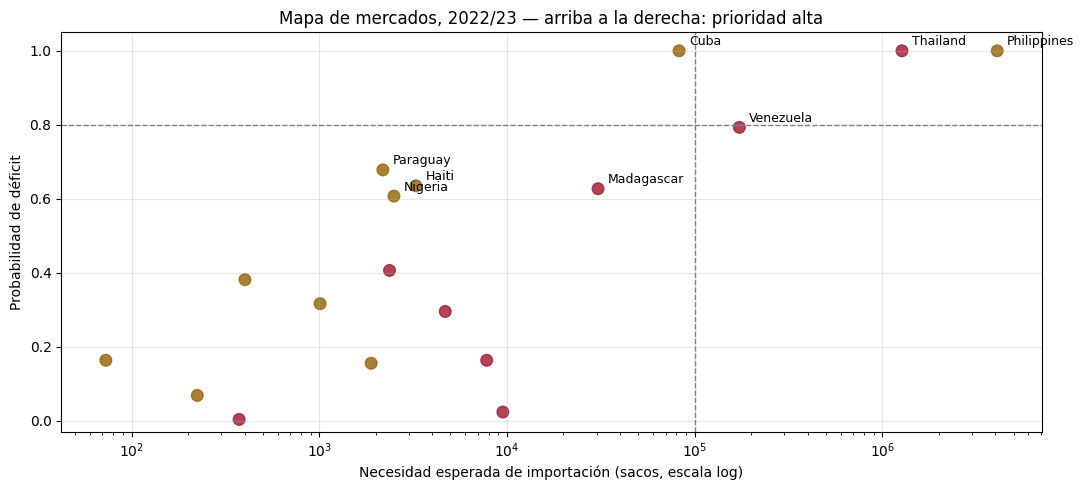

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
datos = ranking[ranking["necesidad_esperada_sacos"] > 0]
colores = np.where(datos["confiabilidad"] == "normal", "#A3243B", "#9A6A12")
ax.scatter(datos["necesidad_esperada_sacos"], datos["prob_deficit"], s=70, c=colores, alpha=0.85)
for pais in recomendacion.index:
    if pais in datos.index:
        ax.annotate(pais, (datos.loc[pais, "necesidad_esperada_sacos"], datos.loc[pais, "prob_deficit"]),
                    textcoords="offset points", xytext=(7, 4), fontsize=9)
ax.set_xscale("log")
ax.axhline(0.8, color="grey", linestyle="--", linewidth=1)
ax.axvline(100_000, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Necesidad esperada de importación (sacos, escala log)")
ax.set_ylabel("Probabilidad de déficit")
ax.set_title(f"Mapa de mercados, {ANIO_OBJETIVO} — arriba a la derecha: prioridad alta")
ax.set_ylim(-0.03, 1.05)
plt.tight_layout()
plt.show()

## 5.4 Qué tan lejos está esto de una decisión de compra

El criterio pedía que cada mercado priorizado tuviera una explicación. Vale la pena ser explícito sobre lo que el número
**no** dice: cuánto café necesita importar un país no es lo mismo que cuánto puede venderle High Garden ni a qué margen.

La ficha por mercado deja a la vista el histórico que sustenta la proyección, para que el área comercial vea de dónde sale.

In [8]:
def ficha(pais):
    hist = balance[balance["country"] == pais].set_index("crop_year")
    proy = proyeccion[proyeccion["country"] == pais].set_index("crop_year")
    fila = ranking.loc[pais]
    miles = lambda x: f"{x:,.0f}".replace(",", ".")
    return pd.Series({
        "tipo de café": fila["coffee_type"],
        "consumo 2019/20 (sacos)": miles(hist.loc["2019/20", "consumo_sacos"]),
        "producción 2019/20 (sacos)": miles(hist.loc["2019/20", "produccion_sacos"]),
        "balance 2019/20 (sacos)": miles(hist.loc["2019/20", "excedente_sacos"]),
        "años en déficit (histórico)": int(hist["flag_deficit"].sum()),
        f"balance mediano {ANIO_OBJETIVO}": miles(proy.loc[ANIO_OBJETIVO, "balance_mediano_sacos"]),
        f"necesidad esperada {ANIO_OBJETIVO}": miles(fila["necesidad_esperada_sacos"]),
        "probabilidad de déficit": f"{fila['prob_deficit']:.0%}",
        "confiabilidad": fila["confiabilidad"],
        "modelo (consumo / producción)": f"{fila['modelo_consumo']} / {fila['modelo_produccion']}",
    })

pd.DataFrame({p: ficha(p) for p in recomendacion.index[:4]})

,Philippines,Thailand,Venezuela,Cuba
tipo de café,Robusta/Arabica,Robusta/Arabica,Arabica,Arabica
consumo 2019/20 (sacos),3.250.000,1.400.000,1.275.000,216.000
producción 2019/20 (sacos),306.534,516.578,650.105,130.183
balance 2019/20 (sacos),-2.943.466,-883.422,-624.895,-85.817
años en déficit (histórico),22,9,15,17
balance mediano 2022/23,-3.753.609,-1.101.385,-188.287,-86.945
necesidad esperada 2022/23,4.088.042,1.270.967,173.015,82.582
probabilidad de déficit,100%,100%,79%,100%
confiabilidad,baja: producción con serie corta,normal,normal,baja: consumo con serie plana
modelo (consumo / producción),drift / ingenuo,drift / ets,ets / ingenuo,ingenuo / ingenuo


## 5.5 Revisión del proceso

Más allá del resultado, CRISP-DM pide revisar cómo se llegó a él: qué quedó sólido y qué quedó débil.

In [9]:
revision = pd.DataFrame([
    ["Procedencia y unidades verificadas antes de analizar", "Sólido",
     "Evitó un error de factor 60 que habría invalidado todo el balance"],
    ["Ceros tratados como faltantes y países segmentados", "Sólido",
     "Sin falsos déficits; el modelado corre solo donde hay señal"],
    ["Backtesting de origen móvil al horizonte del negocio", "Sólido",
     "El error reportado es el del uso real, no el de un split arbitrario"],
    ["Incertidumbre a partir de los errores propios del modelo", "Sólido",
     "El indicador expresa volumen y certeza en una sola cifra en sacos"],
    ["Calibración en la zona intermedia", "Débil",
     "Con probabilidades entre 50 % y 95 % el método sobreestima el déficit"],
    ["Consumo y producción simulados por separado", "Débil",
     "Ignora choques comunes; probablemente subestima la incertidumbre conjunta"],
    ["Selección de modelo con todos los orígenes", "Débil",
     "Hace la validación de calibración algo optimista"],
    ["Series planas y series cortas", "Débil",
     "Cuba y Filipinas dependen de supuestos fuertes; van marcadas en el ranking"],
], columns=["Aspecto", "Estado", "Consecuencia"])
revision

,Aspecto,Estado,Consecuencia
0,Procedencia y unidades verificadas antes de an...,Sólido,Evitó un error de factor 60 que habría invalid...
1,Ceros tratados como faltantes y países segment...,Sólido,Sin falsos déficits; el modelado corre solo do...
2,Backtesting de origen móvil al horizonte del n...,Sólido,"El error reportado es el del uso real, no el d..."
3,Incertidumbre a partir de los errores propios ...,Sólido,El indicador expresa volumen y certeza en una ...
4,Calibración en la zona intermedia,Débil,Con probabilidades entre 50 % y 95 % el método...
5,Consumo y producción simulados por separado,Débil,Ignora choques comunes; probablemente subestim...
6,Selección de modelo con todos los orígenes,Débil,Hace la validación de calibración algo optimista
7,Series planas y series cortas,Débil,Cuba y Filipinas dependen de supuestos fuertes...


## 5.6 Decisión

**Se despliega, con alcance acotado.** El pipeline responde la pregunta de negocio con evidencia trazable y ordena los
mercados de forma estable. Lo que no soporta es leerse como una probabilidad literal en la zona intermedia.

**Cómo debe usarse**
- Como **herramienta de priorización**: qué mercados mirar primero, con qué tipo de café y con qué volumen potencial.
- Como **sistema de alerta**: los casos con probabilidad muy alta y volumen relevante son los que merecen acción comercial.
- **No** como pronóstico puntual del déficit de un país ni como estimación de rentabilidad.

**Qué falta para cerrar la decisión comercial**
1. **Precios y costos.** Sin ellos no hay margen ni rentabilidad; es la mayor limitación del ejercicio.
2. **Barreras de entrada.** Aranceles, acuerdos comerciales y competencia ya instalada en cada mercado.
3. **Datos recientes.** La serie termina en 2019/20; con los años posteriores se puede verificar el acierto real de estas proyecciones.

**Próxima iteración, en orden de impacto**
1. Modelar consumo y producción de forma conjunta, para capturar choques comunes y corregir la sobreestimación.
2. Recalibrar las probabilidades con la evidencia del backtesting antes de publicarlas.
3. Incorporar la serie de exportaciones de la ICO para contrastar el excedente aparente contra las exportaciones reales.
4. Sumar población y PIB per cápita como variables explicativas del consumo interno.